# Chapter 3, Exercise 2: Measuring the F2 signature of emphasis

> **How to use this notebook.** Open it in Google Colab (File > Upload notebook, or the Colab badge on the companion website), then run the cells from top to bottom. Runtime > Change runtime type lets you pick a GPU when one is recommended below. Everything else runs on the free CPU tier.

## The exercise

**Chapter 3, Exercise 2.** Extract several instances of emphatic /tˤ/ and plain /t/ words (for example طين /tˤiːn/ 'mud' and تين /tiːn/ 'figs') from an Arabic corpus such as SADA or Common Voice. Using Python and a formant tracker, measure the second formant near the vowel onset and again at the midpoint for each set, and plot the two distributions; state which spectrogram view, narrowband or wideband, you used to locate the vowel and why. If you cannot locate enough suitable tokens in a corpus, use the provided minimal-pair clips. Report the number of tokens, the speaker and dialect if known, the formant-tracker settings, the median F2 for each class at each measurement point, and a plot of the two distributions.

**Note on data.** The book's minimal-pair clips were not included in the material supplied for these solutions, and SADA and Common Voice require registration or a Kaggle/Hugging Face login. The notebook therefore has two paths: (A) upload your own tokens (WAV plus a CSV of vowel boundaries), or (B) a **clearly labelled synthetic fallback** that generates /tiːn/ and /tˤiːn/ tokens with a source-filter synthesizer whose F2 trajectories follow the values the book reports for the author's recording (about 2580 Hz and 1840 Hz at 30 ms after voicing onset, Figure 2.4). Path B exercises the measurement pipeline; its numbers are not measurements of real speech.

## Requirements

No GPU is required; the notebook runs on Colab's free CPU runtime.

## Testing status

Path B (synthetic fallback) was executed end to end. Path A (real tokens) uses the same measurement code but was not run on a corpus, because the corpora named in the exercise need registration; it is therefore untested on real audio in this release.


In [1]:
!pip install -q praat-parselmouth soundfile pandas matplotlib scipy

## 1. Choose the data path

* **Path A (real tokens).** Put your WAV files in a folder and describe them in `tokens.csv` with columns `file,word,class,vowel_start,vowel_end,speaker,dialect`, where `class` is `plain` or `emphatic` and the vowel boundaries are in seconds. You can mark boundaries in Praat (Chapter 7 walkthrough) or with the wideband spectrogram below.
* **Path B (synthetic fallback, default).** Leave `USE_REAL_TOKENS = False`.

In [2]:
import os, numpy as np, pandas as pd, soundfile as sf, matplotlib.pyplot as plt
from scipy import signal
USE_REAL_TOKENS = False
FS = 16_000
os.makedirs("tokens", exist_ok=True)

if USE_REAL_TOKENS:
    try:
        from google.colab import files
        files.upload()   # upload tokens.csv and the WAV files
    except ImportError:
        pass
    tokens = pd.read_csv("tokens.csv")
    DATA_LABEL = "real tokens (uploaded)"
else:
    # ---- Synthetic fallback: ILLUSTRATIVE DATA, NOT REAL SPEECH ----
    rng = np.random.default_rng(0)
    def resonator_coefs(fc, bw, fs):
        # second-order all-pole resonator (Klatt-style)
        r = np.exp(-np.pi*bw/fs); th = 2*np.pi*fc/fs
        return np.array([1 - 2*r*np.cos(th) + r*r]), np.array([1, -2*r*np.cos(th), r*r])

    def synth_token(f2_onset, f2_target, f0=120.0, vowel_dur=0.22, fs=FS):
        # burst of the /t/ (noise) followed by a vowel with time-varying formants
        n_v = int(vowel_dur*fs)
        # glottal source: impulse train shaped to a -12 dB/octave roll-off
        src = np.zeros(n_v); src[::int(fs/f0)] = 1.0
        src = signal.lfilter([1], [1, -0.97], src); src = signal.lfilter([1], [1, -0.9], src)
        # F2 trajectory: held at the onset value for 30 ms, then rising linearly to the target by 90 ms
        tt = np.arange(n_v)/fs
        f2 = np.where(tt < 0.03, f2_onset,
                      np.where(tt < 0.09, f2_onset + (f2_target - f2_onset)*(tt - 0.03)/0.06, f2_target))
        formants = [(lambda s: 330.0, 70), (lambda s: f2[s], 100), (lambda s: 3000.0, 160),
                    (lambda s: 3800.0, 200), (lambda s: 4600.0, 250)]
        out = src.copy(); blk = 80          # 5 ms blocks, filter state carried across blocks
        for fc_fn, bw in formants:
            y = np.zeros(n_v); zi = np.zeros(2)
            for s in range(0, n_v, blk):
                b, a = resonator_coefs(fc_fn(s), bw, fs)
                y[s:s+blk], zi = signal.lfilter(b, a, out[s:s+blk], zi=zi)
            out = y
        env = np.minimum(1, tt/0.015) * np.minimum(1, (vowel_dur - tt)/0.04)   # onset/offset ramps
        vowel = out*env
        burst = rng.normal(0, 1, int(0.012*fs)) * np.hanning(int(0.012*fs))
        burst = signal.lfilter(*signal.butter(2, [2000, 6000], btype='band', fs=fs), burst) * 0.3
        gap = np.zeros(int(0.010*fs))
        n_seg = np.zeros(int(0.08*fs))   # stand-in for the final nasal (not modelled)
        y = np.concatenate([burst, gap, vowel, n_seg])
        y = y / (np.abs(y).max() + 1e-9) * 0.8
        v_start = (len(burst) + len(gap)) / fs
        return y.astype(np.float32), v_start, v_start + vowel_dur

    rows = []
    for cls, f2_on, f2_tg in [("plain", 2580, 2450), ("emphatic", 1840, 2350)]:
        for k in range(12):
            y, vs, ve = synth_token(f2_on + rng.normal(0, 60), f2_tg + rng.normal(0, 50),
                                    f0=120 + rng.normal(0, 8))
            fname = f"tokens/{cls}_{k:02d}.wav"; sf.write(fname, y, FS)
            rows.append({"file": fname, "word": "تين" if cls == "plain" else "طين", "class": cls,
                         "vowel_start": vs, "vowel_end": ve, "speaker": "synthetic", "dialect": "n/a"})
    tokens = pd.DataFrame(rows)
    DATA_LABEL = "SYNTHETIC illustrative tokens (source-filter synthesizer), not real speech"
print(DATA_LABEL); print(tokens.groupby("class").size())

SYNTHETIC illustrative tokens (source-filter synthesizer), not real speech
class
emphatic    12
plain       12
dtype: int64


## 2. Locate the vowel: wideband versus narrowband view

To find the **onset of voicing** and the vowel edges we use a **wideband** spectrogram (short window, about 5 ms). A short window smears frequency but gives sharp time resolution: the burst, the first glottal pulse and the formant bands are visible as events in time. A **narrowband** view (long window, about 30 ms) resolves the individual harmonics and is the right tool for pitch, but it blurs the vowel onset and hides the formants behind harmonic lines (Section 3.4 and Figure 3.5). Both are drawn below for one token of each class.

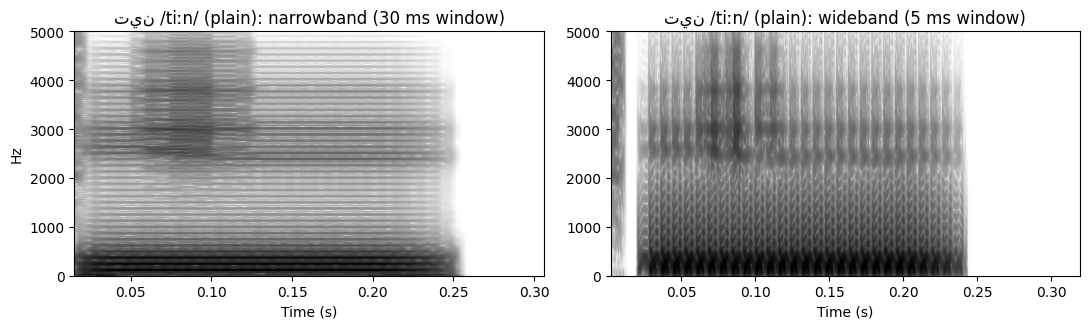

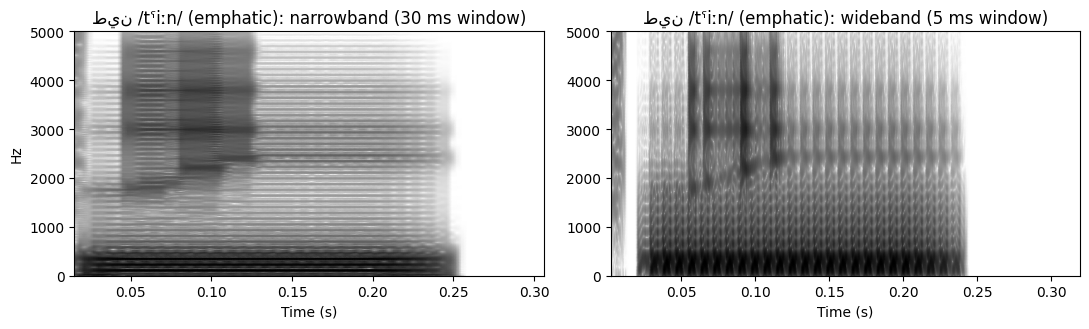

In [3]:
def show_views(path, title):
    y, fs = sf.read(path)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for a, win_ms, name in [(ax[0], 30, 'narrowband (30 ms window)'), (ax[1], 5, 'wideband (5 ms window)')]:
        nper = int(win_ms/1000*fs)
        f, tt, S = signal.spectrogram(y, fs=fs, nperseg=nper, noverlap=int(nper*0.9), nfft=1024)
        a.pcolormesh(tt, f, 10*np.log10(S + 1e-12), shading='gouraud', cmap='gray_r')
        a.set_ylim(0, 5000); a.set_title(f"{title}: {name}"); a.set_xlabel('Time (s)')
    ax[0].set_ylabel('Hz'); plt.tight_layout(); plt.show()

show_views(tokens[tokens["class"] == "plain"].iloc[0]["file"], "تين /tiːn/ (plain)")
show_views(tokens[tokens["class"] == "emphatic"].iloc[0]["file"], "طين /tˤiːn/ (emphatic)")

## 3. Measure F2 with a formant tracker (Praat via parselmouth)

**Tracker settings** (report these with your results): Praat *To Formant (burg)*, time step 5 ms, maximum number of formants 5, maximum formant frequency 5000 Hz (typical for an adult male voice; use 5500 Hz for a female voice; adjust by inspection), window length 25 ms, pre-emphasis from 50 Hz. F2 is read at two points inside the vowel: **onset** = 30 ms after the start of voicing (the point used in Figure 2.4) and **midpoint** = half-way between the vowel boundaries.

In [4]:
import parselmouth
from parselmouth.praat import call

SETTINGS = dict(time_step=0.005, max_formants=5, max_hz=5000, window=0.025, preemph=50)
ONSET_OFFSET = 0.030   # seconds after voicing onset

def f2_at(formant, t):
    return call(formant, "Get value at time", 2, t, "Hertz", "Linear")

results = []
for _, r in tokens.iterrows():
    snd = parselmouth.Sound(r["file"])
    fmt = call(snd, "To Formant (burg)", SETTINGS["time_step"], SETTINGS["max_formants"],
               SETTINGS["max_hz"], SETTINGS["window"], SETTINGS["preemph"])
    t_on = r["vowel_start"] + ONSET_OFFSET
    t_mid = 0.5*(r["vowel_start"] + r["vowel_end"])
    results.append({"file": r["file"], "class": r["class"], "speaker": r["speaker"], "dialect": r["dialect"],
                    "F2_onset": f2_at(fmt, t_on), "F2_mid": f2_at(fmt, t_mid)})
res = pd.DataFrame(results)
summary = res.groupby("class")[["F2_onset", "F2_mid"]].median().round(0)
print("Data:", DATA_LABEL)
print("Tokens per class:", res.groupby("class").size().to_dict())
print("Median F2 (Hz):"); print(summary)

Data: SYNTHETIC illustrative tokens (source-filter synthesizer), not real speech
Tokens per class: {'emphatic': 12, 'plain': 12}
Median F2 (Hz):
          F2_onset  F2_mid
class                     
emphatic    1888.0  2324.0
plain       2613.0  2426.0


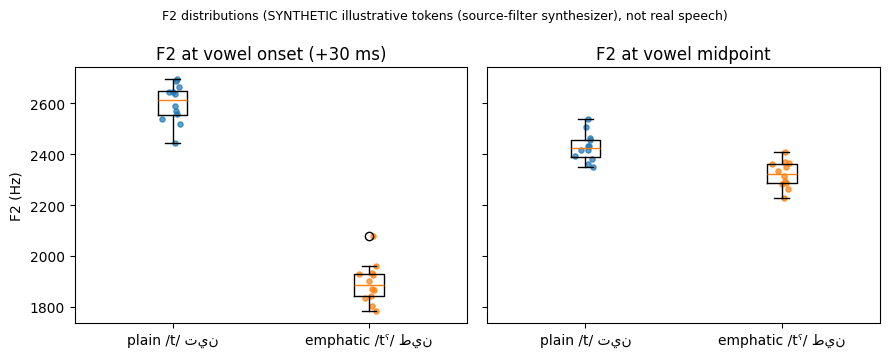

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for a, col, title in [(ax[0], "F2_onset", "F2 at vowel onset (+30 ms)"), (ax[1], "F2_mid", "F2 at vowel midpoint")]:
    data = [res[res["class"] == c][col].dropna().values for c in ["plain", "emphatic"]]
    a.boxplot(data, tick_labels=["plain /t/ تين", "emphatic /tˤ/ طين"])
    for i, d in enumerate(data, start=1):
        a.scatter(np.full(len(d), i) + np.random.default_rng(1).normal(0, 0.04, len(d)), d, s=14, alpha=0.7)
    a.set_title(title)
ax[0].set_ylabel("F2 (Hz)")
plt.suptitle(f"F2 distributions ({DATA_LABEL})", fontsize=9); plt.tight_layout(); plt.show()

## 4. Report template

Fill in from the cells above. For the synthetic fallback the report must say so explicitly.

> **Data:** _N_ tokens per class (word list: تين, طين, ...), speaker(s): _, dialect: _ (or "synthetic illustrative tokens, no speaker"). **View used to locate the vowel:** wideband spectrogram (5 ms window) because its time resolution shows the burst and the first glottal pulse; a narrowband view was used only to confirm voicing. **Tracker:** Praat Burg LPC via parselmouth, time step 5 ms, 5 formants, ceiling 5000 Hz, window 25 ms, pre-emphasis 50 Hz. **Measurement points:** onset = voicing onset + 30 ms; midpoint of the vowel. **Median F2:** plain onset _ Hz, emphatic onset _ Hz; plain mid _ Hz, emphatic mid _ Hz. **Observation:** the emphatic class shows a lower F2 at onset and the gap narrows by the midpoint, consistent with the "recovery" the book describes in Figure 2.4.

**Interpretation.** Emphasis is signalled by a lowered F2 at the *edge of the vowel nearest the consonant*; by the midpoint the tongue has largely recovered, so the two distributions overlap more. This is why onset and midpoint measurements answer different questions, and why a front end must keep enough frequency and time resolution to preserve the onset transition (Section 3.9).